# Milestone Project 1 : Food Vision

See the version of this notebook on GitHub referring my teacher :  
https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/TEMPLATE_07_food_vision_milestone_project_1.ipynb

Check GPU

In [1]:
!nvidia-smi

Fri May 29 13:04:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

https://www.tensorflow.org/guide/mixed_precision?hl=tr

Tesla T4 Compute Capability Point : 7.5  
It's enough for me.  
You can buy `100 Processing Unit`.It's cheap.  

https://developer.nvidia.com/cuda/gpus

## Get helper functions

Rather than rewrite some functions, we can import a script and load them from there.  


In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py


--2026-05-29 13:04:48--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-29 13:04:48 (93.2 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Use TensorFlow Datasets to download data

https://www.tensorflow.org/datasets?hl=tr

https://www.tensorflow.org/datasets/catalog/overview?hl=tr#all_datasets

This provides us to download in Tensor format.Ready to modelling.

In [4]:
import tensorflow_datasets as tfds

In [5]:
datasets_list = tfds.list_builders() # get all avaible datasets in TFDS
print("food101" in datasets_list) # is our target dataset in the list?

True


In [6]:
# Load in the data (takes 5-6 minutes in Google Colab) file is 5 gb i guess.
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True, # data gets returned in tuple (data, label)
                                             with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.GIH2IV_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.GIH2IV_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [7]:
# Features of Food101 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [8]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [9]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [10]:
# Take one sample of the train data
train_data_one_sample = train_data.take(1) # samples are in format (image_tensor, label)
# What does one sample of our training data look like?
train_data_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [11]:
# Output info about our training sample
for image, label in train_data_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image dtype: {image.dtype}
  Target class from Food101: {label}
  Class name (from Food101 metadata): {class_names[label]}
  """)


  Image shape: (512, 512, 3)
  Image dtype: <dtype: 'uint8'>
  Target class from Food101: 49
  Class name (from Food101 metadata): grilled_cheese_sandwich
  


In [12]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[239, 217, 157],
        [244, 222, 162],
        [247, 227, 168],
        ...,
        [119, 104,  73],
        [111,  95,  70],
        [105,  89,  66]],

       [[233, 212, 149],
        [239, 218, 155],
        [243, 223, 162],
        ...,
        [117, 102,  71],
        [108,  92,  67],
        [101,  85,  62]],

       [[227, 206, 139],
        [234, 213, 146],
        [238, 219, 153],
        ...,
        [117, 100,  70],
        [108,  91,  65],
        [101,  83,  59]],

       ...,

       [[ 35,   7,  19],
        [ 35,   7,  19],
        [ 36,   8,  20],
        ...,
        [198, 181, 127],
        [196, 179, 125],
        [193, 176, 122]],

       [[ 34,   6,  18],
        [ 34,   6,  18],
        [ 35,   7,  19],
        ...,
        [200, 183, 129],
        [201, 184, 130],
        [198, 181, 127]],

       [[ 33,   5,  17],
        [ 34,   6,  18],
        [ 35,   7,  19],
        ...,
        [203, 186, 13

In [13]:
import tensorflow as tf

In [14]:
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TensorFlow Datasets

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

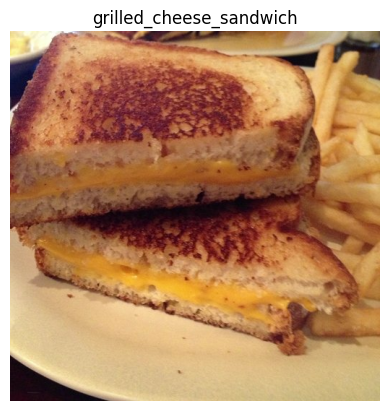

In [15]:
# Plot an image tensor
import matplotlib.pyplot as plt
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

## Create preprocessing functions for our data

neural networks perform best when data is in a certain way (e.g. batched, normalized etc.)  

⚓ What we know about our data:  
* In `uint8` datatype
* Comprised of all different size tensors
* Not scaled (0-255 now)

What we know models like:  
* Data in `float32` dtype (or for mixed precision `float32` and `float16`).  
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size.  
* Scaled (values between 0 & 1) normalization.  

With these points in mind, we've got a few things we can tackle with a preprocessing function.  

If you'll use pre-trained models like efficientnet etc. you don't need to normalize.  

This means our functions needs to:  
1. Reshape our images to all the same size.  
2. Convert the dtype of our image tensors from `unit8` to `float32`.  




In [16]:
# Make a function for preprocessing images
def preprocessing_img(image, label, img_shape=224): #target shape depends to you.
  """
  Converts image data type from 'uint8' -> 'float32'
  Reshapes image to [img_shape, img_shape, color_channels]
  """
  image = tf.image.resize(image, [img_shape, img_shape])
  #image = image / 255. # no need for efficientnetbx
  return tf.cast(image, tf.float32), label


In [17]:
# Preprocess a single sample image and check the outputs
preprocessed_img = preprocessing_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2], image.shape, image.dtype}\n")
print(f"Image after preprocessing:\n {preprocessed_img[:2], preprocessed_img.shape, preprocessed_img.dtype}")

Image before preprocessing:
 (<tf.Tensor: shape=(2, 512, 3), dtype=uint8, numpy=
array([[[239, 217, 157],
        [244, 222, 162],
        [247, 227, 168],
        ...,
        [119, 104,  73],
        [111,  95,  70],
        [105,  89,  66]],

       [[233, 212, 149],
        [239, 218, 155],
        [243, 223, 162],
        ...,
        [117, 102,  71],
        [108,  92,  67],
        [101,  85,  62]]], dtype=uint8)>, TensorShape([512, 512, 3]), tf.uint8)

Image after preprocessing:
 (<tf.Tensor: shape=(2, 224, 3), dtype=float32, numpy=
array([[[238.7704  , 217.41327 , 155.4847  ],
        [242.83673 , 222.83673 , 162.55101 ],
        [240.85713 , 220.20918 , 164.2143  ],
        ...,
        [131.28564 , 118.28565 ,  75.7806  ],
        [123.88257 , 109.81113 ,  75.09689 ],
        [106.698746,  90.698746,  66.4131  ]],

       [[232.16325 , 212.09183 , 141.37755 ],
        [238.86224 , 219.86224 , 151.07654 ],
        [239.94388 , 221.08673 , 155.87245 ],
        ...,
        [12

### Batch & Prepare Datasets

We're now going to make our data input pipeline run really fast.  

For more recourses :  

https://www.tensorflow.org/guide/data_performance?hl=tr



In [18]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [19]:
# Map preprocessing function to training (and parallelize)
train_data = train_data.map(map_func=preprocessing_img, num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train_data and turn it into batches and prefetch it (load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing function to test data
test_data = test_data.map(map_func=preprocessing_img, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

1. `map()` applies the preprocessing function to every `(image, label)` pair in the dataset.
   In this case, it resizes each image to `224x224` and converts the image data type from `uint8` to `float32`.

2. `num_parallel_calls=tf.data.AUTOTUNE` allows TensorFlow to process multiple images in parallel.
   TensorFlow automatically chooses the best number of parallel calls depending on the available system resources.

3. `shuffle(buffer_size=1000)` randomly shuffles the training data.
   This helps the model see mixed examples instead of learning from images in a fixed or grouped order.

4. `batch(batch_size=32)` groups the images into batches of 32.
   Instead of sending one image at a time to the model, TensorFlow sends 32 images together.

5. After batching, the image shape becomes something like `(32, 224, 224, 3)`.
   This means: 32 images, each image is 224 pixels high, 224 pixels wide, and has 3 color channels: Red, Green, and Blue.

6. `prefetch(tf.data.AUTOTUNE)` prepares the next batch while the model is training on the current batch.
   This helps reduce waiting time and keeps the GPU/CPU pipeline faster.

7. The training pipeline usually looks like this:
   raw images → preprocessing → shuffle → batch → prefetch → model training

8. The test pipeline usually does not use `shuffle()`.
   Test data is only preprocessed, batched, and prefetched because we usually do not need to randomize it.


In [20]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Creating modelling callbacks  

We're going to create a couple of callbacks to help us while our model trains:

* TensorBoard callback to log training results (so we can visualize them if need be)  
* ModelCheckpoint callback to save our model's progress after feature extraction.  


In [22]:
# Create tensorboard callback (import from healper_functions.py)
from helper_functions import create_tensorboard_callback

In [24]:
# Create ModelCheckpoint callback to save model's progress during training
checkpoint_path = "model_checkpoint/cp.ckpt.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_accuracy",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      verbose=0)

## Setup mixed precision training

First and foremost, for a deeper understanding, check out the TensorFlow document.  

https://www.tensorflow.org/guide/mixed_precision?hl=tr  

Mixed precision utilizes a combination of float32 and float16 data types to speed up model performance.  


In [32]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

In [34]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Build Feature Extraction Model

In [35]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [36]:
len(class_names)

101

In [37]:
# Create base model
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create functional model
inputs = layers.Input(shape=input_shape)
# x = preprocessing.Rescale(1./255)(x) # if our model wouldn't be EfficientNetB0
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(len(class_names))(x)
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
# Compile
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])


In [40]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [39]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Checking layer dtype policies (are we using mixed precision?)  


In [44]:
# Check the dtype policy attributes of layers in our model
for layer in model.layers:
    print(f"{layer.name},-------- {layer.trainable},----- {layer.dtype},---- {layer.dtype_policy}")

input_layer_1,-------- True,----- float32,---- <DTypePolicy "mixed_float16">
efficientnetb0,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
global_average_pooling2d,-------- True,----- float32,---- <DTypePolicy "mixed_float16">
dense,-------- True,----- float32,---- <DTypePolicy "mixed_float16">
softmax_float32,-------- True,----- float32,---- <DTypePolicy "float32">


In mixed precision training, most layers use float16 for computation and float32 for storing variables/weights. This speeds up training while keeping the model weights stable. The final softmax/output layer is often forced to float32 to produce more numerically stable probability outputs.  

Going through the above we see:  
* `layer.name :` readable name of a particular layer.  
* `layer.trainable :` is the layer trainable or not? (if `False`, the weights are frozen)  
* `layer.dtype :` the data type a layer `stores` its variables in  
* `layer.dtype_policy :` the data type policy a layer `computes` on its variables with  


In [46]:
for layer in model.layers[1].layers: #model.layers[1] -> efficientnetb0
  print(f"{layer.name},-------- {layer.trainable},----- {layer.dtype},---- {layer.dtype_policy}")

input_layer,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
rescaling,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
normalization,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
rescaling_1,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
stem_conv_pad,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
stem_conv,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
stem_bn,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
stem_activation,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
block1a_dwconv,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
block1a_bn,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
block1a_activation,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
block1a_se_squeeze,-------- False,----- float32,---- <DTypePolicy "mixed_float16">
block1a_se_reshape,-------- False,----- float32,---- <DTypePolicy "mixed

In [48]:
for layer in model.layers[1].layers[:3]:
    print(
        layer.name,
        "policy:", layer.dtype_policy,
        "compute:", layer.compute_dtype,
        "variable:", layer.variable_dtype
    )

input_layer policy: <DTypePolicy "mixed_float16"> compute: float16 variable: float32
rescaling policy: <DTypePolicy "mixed_float16"> compute: float16 variable: float32
normalization policy: <DTypePolicy "mixed_float16"> compute: float16 variable: float32


## Fit the feature extraction model

If our goal is to fine-tune a pretrained model, the general order of doing things is:

1. Build a feature extraction model (train a couple output layers with base layers frozen)  
2. Fine-tune some of the frozen layers  


In [50]:
# Fit the feature extractşon model with callbacks
history_feature_extraction = model.fit(train_data,
                                       epochs=3,
                                       steps_per_epoch=len(train_data),
                                       validation_data=test_data,
                                       validation_steps=int(0.15 * len(test_data)),
                                       callbacks=[create_tensorboard_callback(dir_name="logs_feature_extraction",
                                                                              experiment_name="feature_extraction"),
                                                  model_checkpoint])


Saving TensorBoard log files to: logs_feature_extraction/feature_extraction/20260529-145118
Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 276s 89ms/step - accuracy: 0.5691 - loss: 1.7744 - val_accuracy: 0.6994 - val_loss: 1.1377
Epoch 2/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 69ms/step - accuracy: 0.6700 - loss: 1.2670 - val_accuracy: 0.7132 - val_loss: 1.0430
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 186s 78ms/step - accuracy: 0.7043 - loss: 1.1312 - val_accuracy: 0.7248 - val_loss: 0.9952


In [51]:
# Evaluate model on whole test dataset instead of %15 as above
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - accuracy: 0.7278 - loss: 1.0007


[1.0007011890411377, 0.7277624011039734]

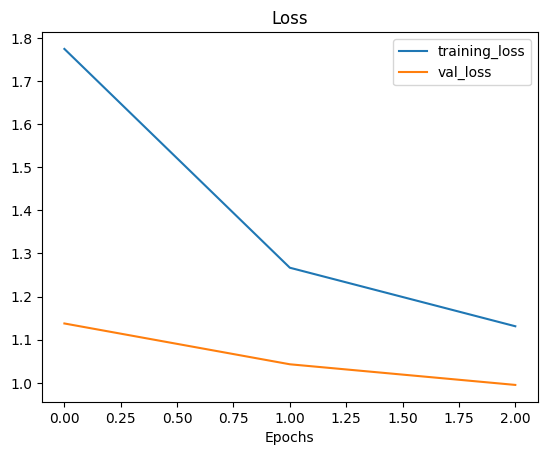

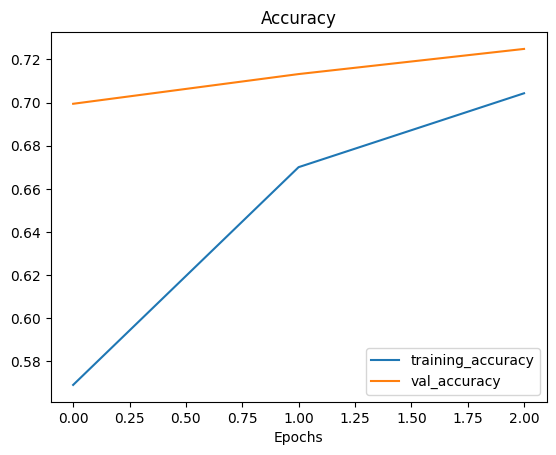

In [52]:
plot_loss_curves(history_feature_extraction)

## END OF TEMPLATE

We've covered a lot of ground so far since this is a milstone project, it's time for us to takeover.  

More specifically, our challemge is to complete the TEMPLATE version of this computer vision model.  
